In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/maazshaikh05/online-learning-behavior-dataset/Online_Learning_Behavior_Dataset_Worldwide.csv


# Predicting Progress in Online Learning

## 1. Introduction

## 2. Import Libraries

## 3. Load the Dataset

## 4. Initial Data Inspection

## 5. Target Variable and Feature Definition

## 6. Data Quality Checks

## 7. Univariate Analysis

## 8. Bivariate Analysis

## 9. Data Preprocessing

## 10. Model Building

## 11. Conclusion

## 1. Introduction

Online courses have become a common way for people to build skills, whether for education, work, or personal development. At the same time, it is easy to start a course and never get very far with it.

In this project, I want to look at which factors are linked to making meaningful progress in an online course. I also want to see whether these factors can be used to predict which learners are more likely to get far enough through a course for it to be worthwhile.

## 2. Import Libraries

In [2]:
# Import the main libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a simple plot style
sns.set_style('whitegrid')

## 3. Load the Dataset

I start by loading the dataset and taking a quick look at the first few rows.

In [3]:
# Load the dataset
course_df = pd.read_csv('/kaggle/input/datasets/maazshaikh05/online-learning-behavior-dataset/Online_Learning_Behavior_Dataset_Worldwide.csv')

## 4. Initial Data Inspection

Before doing any analysis, I want to get a basic sense of the dataset: how large it is, what columns it contains, and whether there are any obvious issues with data types or missing values.

In this section, I inspect the structure of the dataset, including the number of observations, feature names, data types, and summary statistics. This helps identify the available predictors, understand the target variable, and detect any early data quality issues before moving into exploratory analysis.

In [4]:
course_df.head(10)

,Student_ID,Country,Age,Gender,Education_Level,Field_of_Study,Platform_Used,Device_Used,Learning_Mode,Enrollment_Date,Daily_Learning_Hours,Quizzes_Attempted,Assignments_Submitted,Course_Completion_Rate(%),Satisfaction_Score(1-5)
0,1,South Africa,21,Other,High School,Medicine,Khan Academy,Mobile,Self-Paced,2023-11-24,4.58,7,3,28.91,2
1,2,South Africa,49,Female,Undergraduate,Arts,Udacity,Tablet,Self-Paced,2023-02-17,3.28,0,8,37.49,2
2,3,UK,20,Female,High School,Engineering,edX,Tablet,Self-Paced,2023-03-23,2.37,4,3,75.85,3
3,4,France,38,Other,Undergraduate,Data Science,Coursera,Mobile,Hybrid,2023-08-24,5.85,12,1,62.90,5
4,5,France,44,Other,Postgraduate,Business,edX,Tablet,Self-Paced,2023-04-27,5.92,7,1,81.85,4
5,6,Brazil,25,Other,Undergraduate,Business,Khan Academy,Desktop,Instructor-Led,2023-12-10,5.65,20,1,41.36,5
6,7,USA,35,Female,Postgraduate,Computer Science,Udemy,Tablet,Self-Paced,2023-11-24,1.71,10,0,75.05,2
7,8,France,23,Male,Postgraduate,Data Science,Udacity,Desktop,Hybrid,2023-12-02,5.37,20,7,59.94,2
8,9,UK,18,Male,Undergraduate,Data Science,Udemy,Desktop,Hybrid,2023-07-24,5.99,4,8,48.96,4
9,10,Japan,15,Other,High School,Data Science,Udacity,Tablet,Hybrid,2023-02-02,3.78,14,8,50.78,3


In [5]:
# Check the shape of the dataset
course_df.shape

(1000, 15)

In [6]:
# Look at the column names
course_df.columns

Index(['Student_ID', 'Country', 'Age', 'Gender', 'Education_Level',
       'Field_of_Study', 'Platform_Used', 'Device_Used', 'Learning_Mode',
       'Enrollment_Date', 'Daily_Learning_Hours', 'Quizzes_Attempted',
       'Assignments_Submitted', 'Course_Completion_Rate(%)',
       'Satisfaction_Score(1-5)'],
      dtype='object')

In [7]:
# Check data types and missing values
course_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_ID                 1000 non-null   int64  
 1   Country                    1000 non-null   object 
 2   Age                        1000 non-null   int64  
 3   Gender                     1000 non-null   object 
 4   Education_Level            1000 non-null   object 
 5   Field_of_Study             1000 non-null   object 
 6   Platform_Used              1000 non-null   object 
 7   Device_Used                1000 non-null   object 
 8   Learning_Mode              1000 non-null   object 
 9   Enrollment_Date            1000 non-null   object 
 10  Daily_Learning_Hours       1000 non-null   float64
 11  Quizzes_Attempted          1000 non-null   int64  
 12  Assignments_Submitted      1000 non-null   int64  
 13  Course_Completion_Rate(%)  1000 non-null   float6

In [8]:
# Summary statistics for numeric columns
course_df.describe()

,Student_ID,Age,Daily_Learning_Hours,Quizzes_Attempted,Assignments_Submitted,Course_Completion_Rate(%),Satisfaction_Score(1-5)
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000
mean,500.500000,32.734000,3.188840,10.12500,5.06200,60.01732,2.903000
std,288.819436,10.456509,1.581955,6.15022,3.17872,23.25666,1.413361
min,1.000000,15.000000,0.510000,0.00000,0.00000,20.00000,1.000000
25%,250.750000,23.000000,1.810000,5.00000,2.00000,39.82750,2.000000
50%,500.500000,33.000000,3.115000,10.00000,5.00000,59.90000,3.000000
75%,750.250000,42.000000,4.560000,16.00000,8.00000,80.88000,4.000000
max,1000.000000,50.000000,6.000000,20.00000,10.00000,99.90000,5.000000


In [9]:
# Summary statistics for categorical columns
course_df.describe(include='object')

,Country,Gender,Education_Level,Field_of_Study,Platform_Used,Device_Used,Learning_Mode,Enrollment_Date
count,1000,1000,1000,1000,1000,1000,1000,1000
unique,13,3,4,6,6,4,3,344
top,South Africa,Female,Professional,Data Science,Udacity,Desktop,Instructor-Led,2023-04-09
freq,88,346,274,184,191,259,343,9


## 5. Defining the Target

The dataset reports course completion as a percentage rather than a binary outcome, so I create two target variables for classification.

The first is `ModerateProgress`, which is defined as completing at least 50% of a course. This gives a lower threshold for learners who got through a meaningful amount of the material, even if they did not get close to finishing.

The second is `MeaningfulProgress`, which is defined as completing at least 75% of a course. This is a stricter threshold and is intended to capture learners who made substantial progress and followed through to a greater extent.

In [10]:
# Create the target
course_df['MeaningfulProgress'] = (course_df['Course_Completion_Rate(%)'] >= 70).astype(int)

# Check class counts
course_df['MeaningfulProgress'].value_counts()

MeaningfulProgress
0    630
1    370
Name: count, dtype: int64

In [11]:
# Check class proportions
course_df['MeaningfulProgress'].value_counts(normalize=True)

MeaningfulProgress
0    0.63
1    0.37
Name: proportion, dtype: float64

In [12]:
# Create the target
course_df['ModerateProgress'] = (course_df['Course_Completion_Rate(%)'] >= 50).astype(int)
# Check class counts
course_df['ModerateProgress'].value_counts()

ModerateProgress
1    621
0    379
Name: count, dtype: int64

In [13]:
# Check class proportions
course_df['ModerateProgress'].value_counts(normalize=True)

ModerateProgress
1    0.621
0    0.379
Name: proportion, dtype: float64

## 6. Feature Groups

Before starting the analysis, I split the variables into groups. This makes it easier to keep track of the ID column, the target variables, and the predictor features.

For this project, I create two target variables: `ModerateProgress` and `MeaningfulProgress`. The rest of the features are treated as predictors, except for the raw course completion percentage, which is used to define the targets and so should not be included in the models.

In [14]:
course_df.describe(include='object').columns

Index(['Country', 'Gender', 'Education_Level', 'Field_of_Study',
       'Platform_Used', 'Device_Used', 'Learning_Mode', 'Enrollment_Date'],
      dtype='object')

In [15]:
# ID column
id_feature = 'Student_ID'

# Target columns
target_1 = 'ModerateProgress'
target_2 = 'MeaningfulProgress'

# Numerical predictor features
numerical_features = [
    'Age',
    'Daily_Learning_Hours',
    'Quizzes_Attempted',
    'Assignments_Submitted',
    'Satisfaction_Score(1-5)'
]

# Categorical predictor features
categorical_features = [
    'Country',
    'Gender',
    'Education_Level',
    'Field_of_Study',
    'Platform_Used',
    'Device_Used',
    'Learning_Mode'
]

# Combine predictor features
predictor_features = numerical_features + categorical_features

## 7. Data Quality Checks

Before moving into the analysis, I check for a few basic data quality issues. In particular, I look at missing values, duplicate rows, and the category labels used in the categorical features.

In [16]:
# Check missing values
course_df.isnull().sum()

Student_ID                   0
Country                      0
Age                          0
Gender                       0
Education_Level              0
Field_of_Study               0
Platform_Used                0
Device_Used                  0
Learning_Mode                0
Enrollment_Date              0
Daily_Learning_Hours         0
Quizzes_Attempted            0
Assignments_Submitted        0
Course_Completion_Rate(%)    0
Satisfaction_Score(1-5)      0
MeaningfulProgress           0
ModerateProgress             0
dtype: int64

In [17]:
# Check duplicate rows
course_df.duplicated().sum()

np.int64(0)

In [18]:
# Check category labels in categorical features
for feature in categorical_features:
    print(feature)
    print(course_df[feature].unique())

Country
['South Africa' 'UK' 'France' 'Brazil' 'USA' 'Japan' 'India' 'UAE'
 'Australia' 'Germany' 'Pakistan' 'Canada' 'China']
Gender
['Other' 'Female' 'Male']
Education_Level
['High School' 'Undergraduate' 'Postgraduate' 'Professional']
Field_of_Study
['Medicine' 'Arts' 'Engineering' 'Data Science' 'Business'
 'Computer Science']
Platform_Used
['Khan Academy' 'Udacity' 'edX' 'Coursera' 'Udemy' 'YouTube Learning']
Device_Used
['Mobile' 'Tablet' 'Desktop' 'Laptop']
Learning_Mode
['Self-Paced' 'Hybrid' 'Instructor-Led']


The dataset looks clean based on these initial checks. There are no missing values, no duplicate rows, and the categorical features use consistent labels. This means very little cleaning is needed at this stage, so I can move on to the exploratory analysis.

## 8. Univariate Analysis

### Target variables


I start by looking at the target variables on their own. This gives a sense of the class balance before moving into the predictor features and later modelling.

In [19]:
# Check class counts for both targets
course_df['ModerateProgress'].value_counts()

ModerateProgress
1    621
0    379
Name: count, dtype: int64

In [20]:
# Check class proportions for ModerateProgress
course_df['ModerateProgress'].value_counts(normalize=True)

ModerateProgress
1    0.621
0    0.379
Name: proportion, dtype: float64

In [21]:
# Check class counts for MeaningfulProgress
course_df['MeaningfulProgress'].value_counts()

MeaningfulProgress
0    630
1    370
Name: count, dtype: int64

In [22]:
# Check class proportions for MeaningfulProgress
course_df['MeaningfulProgress'].value_counts(normalize=True)

MeaningfulProgress
0    0.63
1    0.37
Name: proportion, dtype: float64

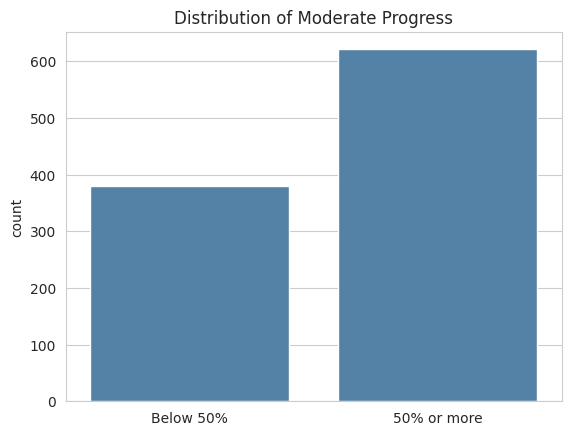

In [23]:
# Create labels for ModerateProgress
course_df['ModerateProgressLabel'] = course_df[target_1].map({
    0: 'Below 50%',
    1: '50% or more'
})

# Plot ModerateProgress
sns.countplot(x='ModerateProgressLabel', data=course_df, color='steelblue')
plt.title('Distribution of Moderate Progress')
plt.xlabel('')
plt.show()

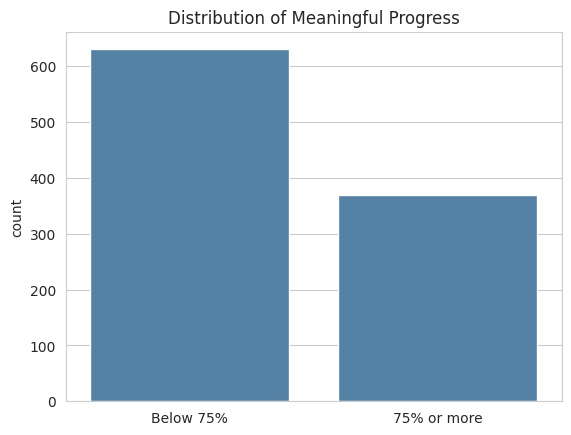

In [24]:
# Create labels for MeaningfulProgress
course_df['MeaningfulProgressLabel'] = course_df[target_2].map({
    0: 'Below 75%',
    1: '75% or more'
})

# Plot MeaningfulProgress
sns.countplot(x='MeaningfulProgressLabel', data=course_df, color='steelblue')
plt.title('Distribution of Meaningful Progress')
plt.xlabel('')
plt.show()

The two target variables have fairly similar class balance overall, but the majority class changes with the threshold. For `ModerateProgress`, most learners fall into the `50% or more` group, while for `MeaningfulProgress`, most learners fall into the `Below 75%` group. This is expected, since `MeaningfulProgress` uses a stricter threshold and therefore classifies fewer learners as having made substantial progress.

### Numerical Features

Next I look at the numerical predictor features on their own. This helps show how the values are distributed and whether there are any obvious issues such as skewness or extreme values.

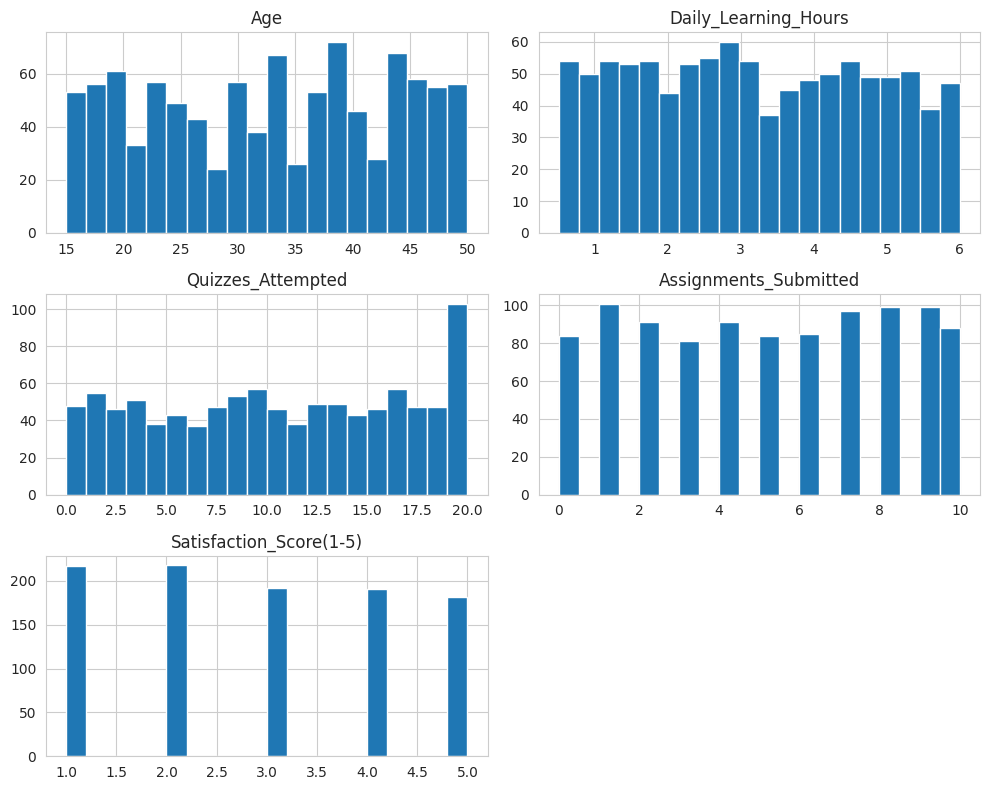

In [25]:
# Histograms for numerical features
course_df[numerical_features].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

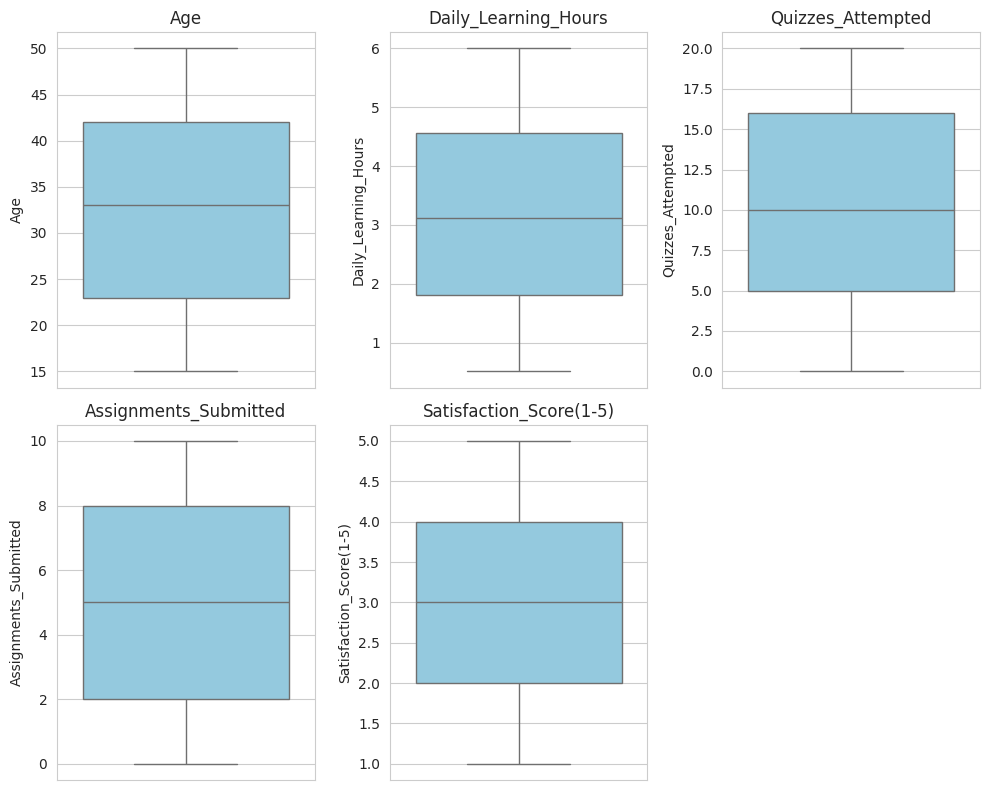

In [26]:
# Boxplots for numerical features
plt.figure(figsize=(10, 8))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=course_df[feature], color='skyblue')
    plt.title(feature)

plt.tight_layout()
plt.show()

The numerical features look fairly clean overall. `Age`, `Daily_Learning_Hours`, `Quizzes_Attempted`, and `Assignments_Submitted` all show a reasonable spread of values, with no obvious signs of severe skewness or extreme outliers. `Satisfaction_Score(1-5)` is discrete, so its stepped pattern is expected. Taken together, the histograms and boxplots suggest that the numerical features are well behaved and should be suitable for later analysis.

### Categorical Features

I now look at the categorical predictor features on their own. This helps show how the observations are distributed across the different groups in the dataset.

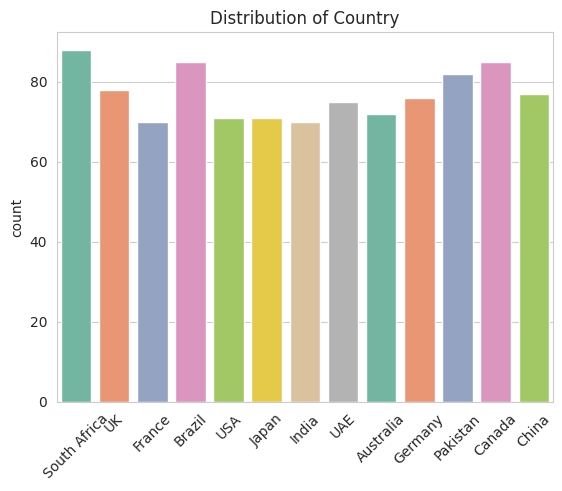

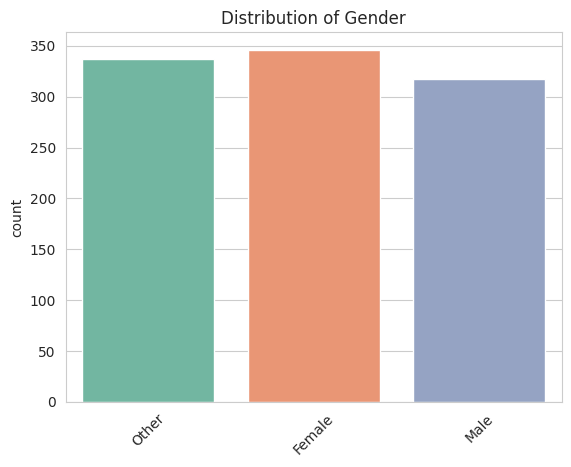

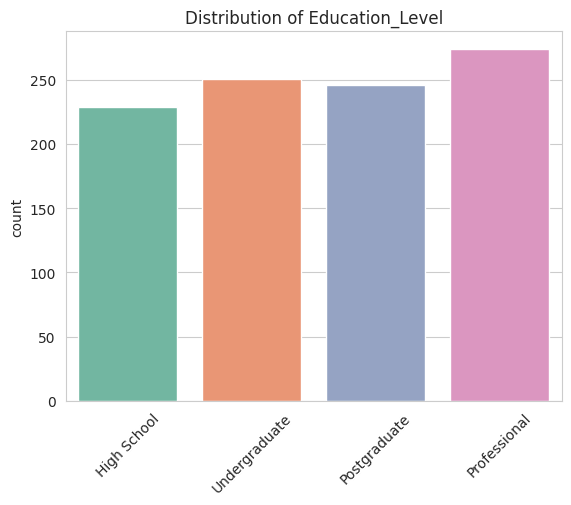

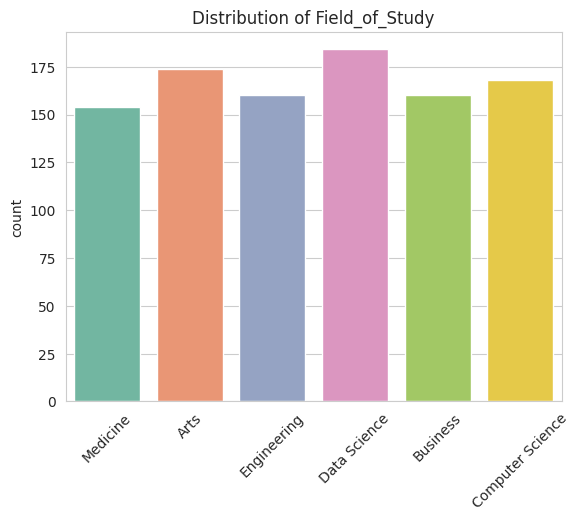

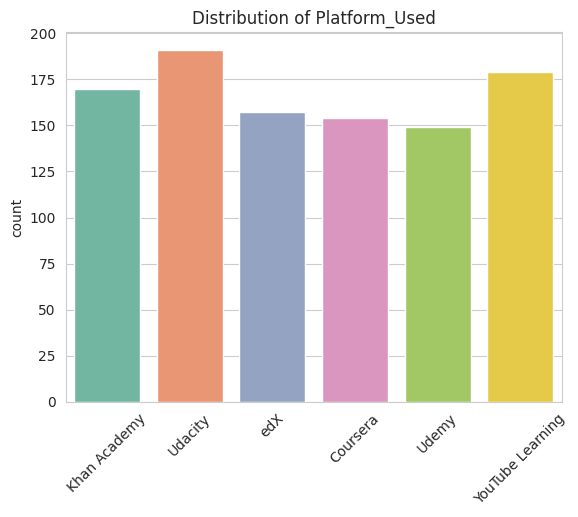

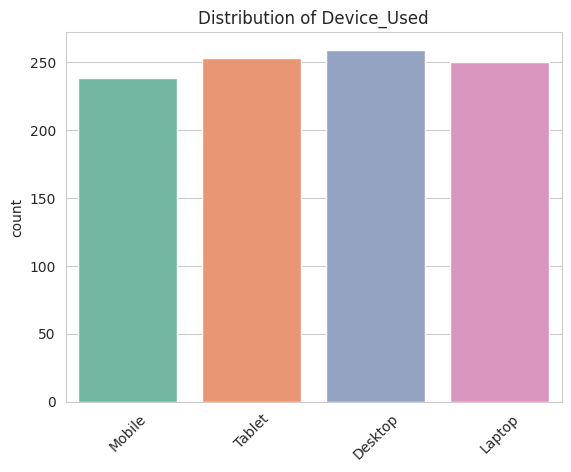

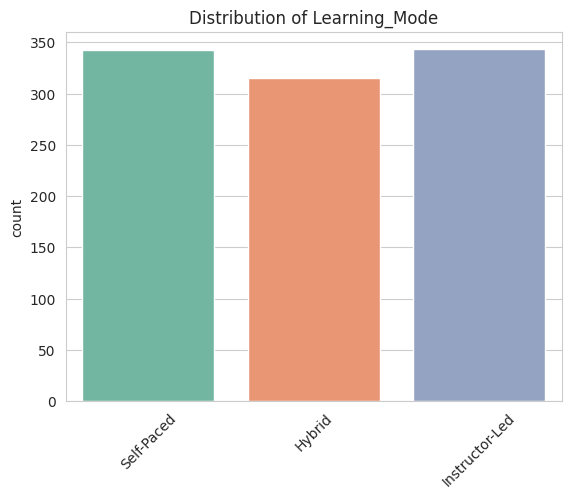

In [27]:
# Countplots for categorical features
for feature in categorical_features:
    sns.countplot(x=feature, hue=feature, data=course_df, palette='Set2', legend=False)
    plt.title(f'Distribution of {feature}')
    plt.xticks(rotation=45)
    plt.xlabel('')
    plt.show()

The categorical features are fairly balanced overall. Most of the variables, including `Country`, `Gender`, `Device_Used`, and `Learning_Mode`, are distributed quite evenly across their categories. `Education_Level`, `Field_of_Study`, and `Platform_Used` show a bit more variation, but no category appears overwhelmingly dominant. Overall, the categorical features look well spread and should be suitable for comparing against the target variables later in the analysis.

## 8. Bivariate Analysis

After looking at the features on their own, I now compare them with the target variable. This helps show which features seem more closely related to learner progress.

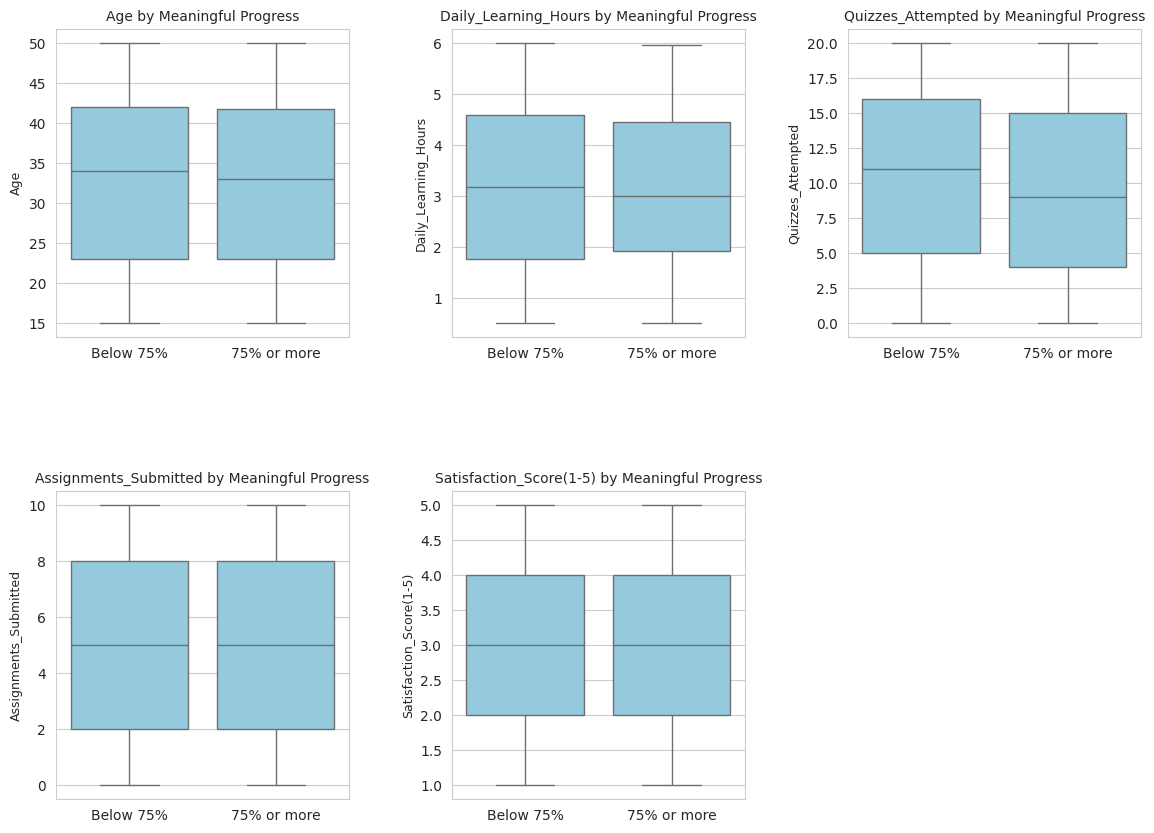

In [28]:
# Boxplots of numerical features by MeaningfulProgress
plt.figure(figsize=(14, 10))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='MeaningfulProgressLabel', y=feature, data=course_df, color='skyblue')
    plt.title(f'{feature} by Meaningful Progress', fontsize=10)
    plt.xlabel('')
    plt.ylabel(feature, fontsize=9)

plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.show()

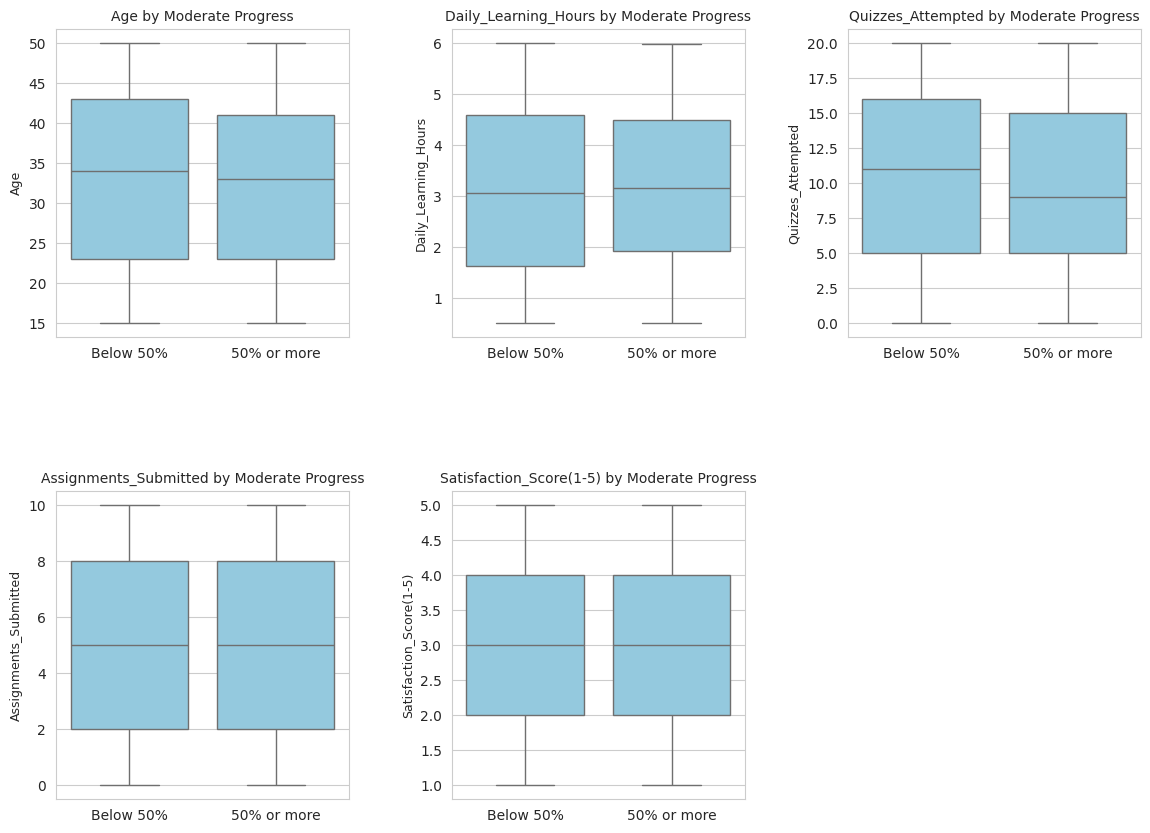

In [29]:
# Boxplots of numerical features by MeaningfulProgress
plt.figure(figsize=(14, 10))

for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='ModerateProgressLabel', y=feature, data=course_df, color='skyblue')
    plt.title(f'{feature} by Moderate Progress', fontsize=10)
    plt.xlabel('')
    plt.ylabel(feature, fontsize=9)

plt.subplots_adjust(hspace=0.5, wspace=0.35)
plt.show()

The numerical features do not show large visual differences across the `MeaningfulProgress` and `ModerateProgress` groups. For `MeaningfulProgress` most features, including `Age`, `Daily_Learning_Hours`, `Assignments_Submitted`, and `Satisfaction_Score(1-5)`, the distributions overlap heavily and the medians are quite similar while `Quizzes_Attempted` shows a bit more separation than the others. For `ModerateProgress` features like `Assignments_Submitted`, and `Satisfaction_Score(1-5)`, the distributions overlap heavily and the medians are quite similar while `Quizzes_Attempted`,  `Age` and `Daily_Learning_Hours` show a bit more separation.  Overall, this suggests that the numerical features may have limited predictive power on their own, but could still be useful when combined in a model.

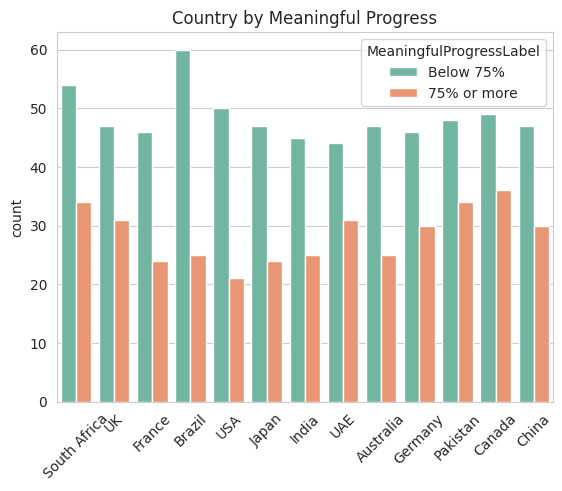

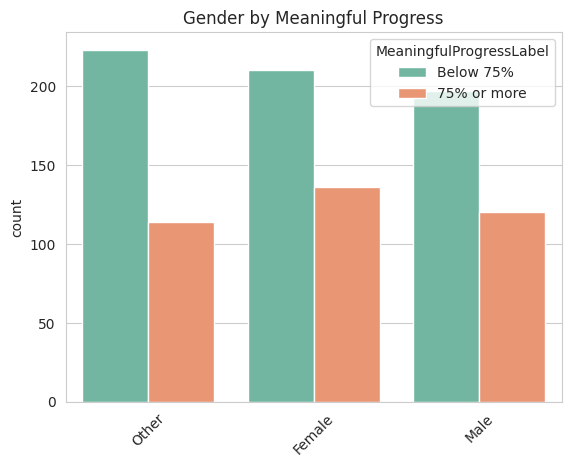

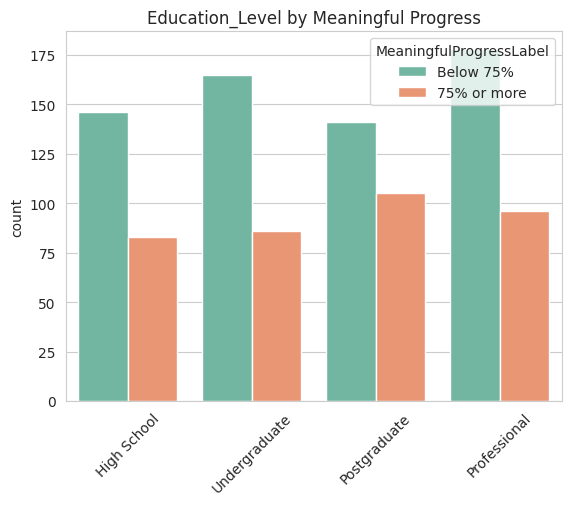

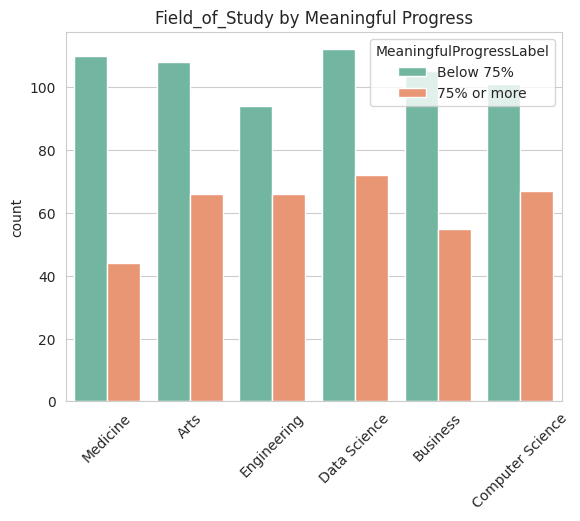

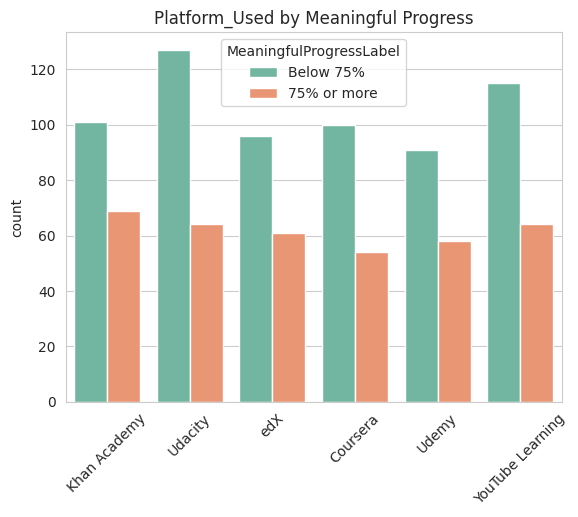

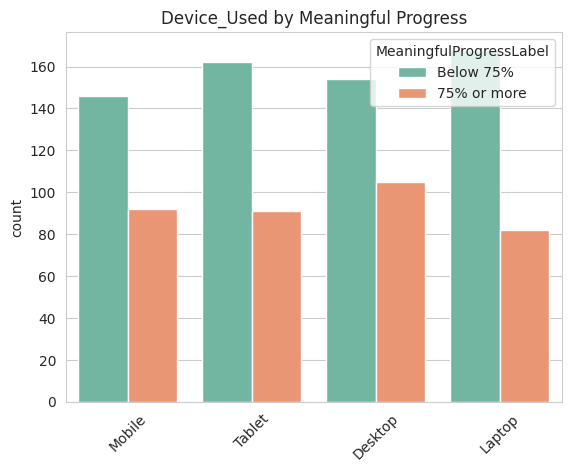

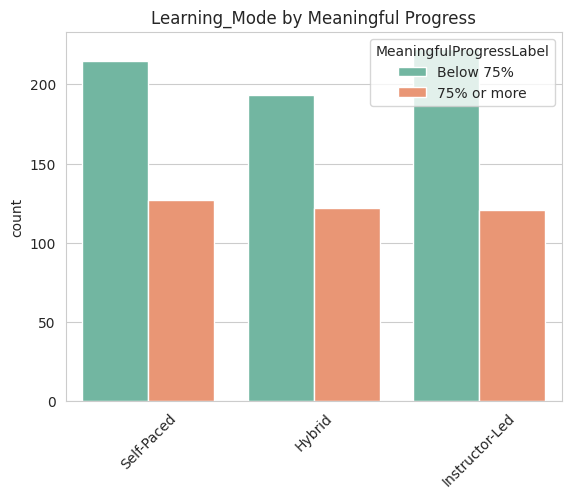

In [30]:
# Countplots of categorical features by MeaningfulProgress
for feature in categorical_features:
    sns.countplot(x=feature, hue='MeaningfulProgressLabel', data=course_df, palette='Set2')
    plt.title(f'{feature} by Meaningful Progress')
    plt.xticks(rotation=45)
    plt.xlabel('')
    plt.show()

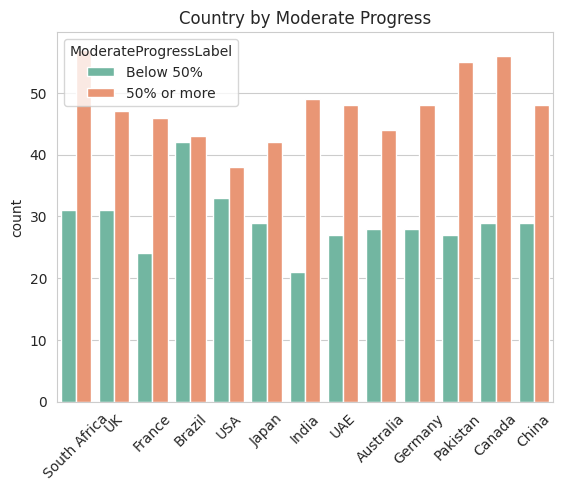

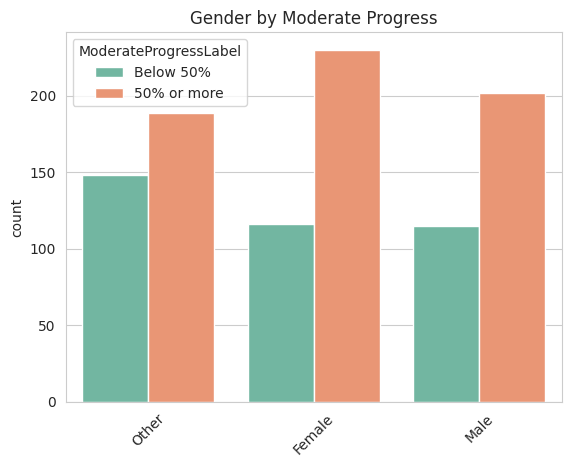

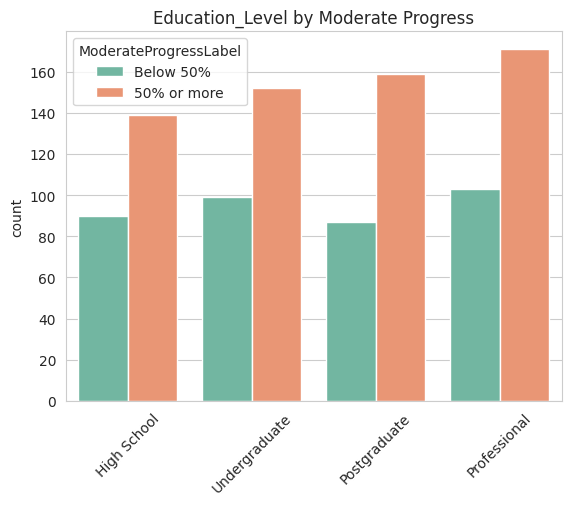

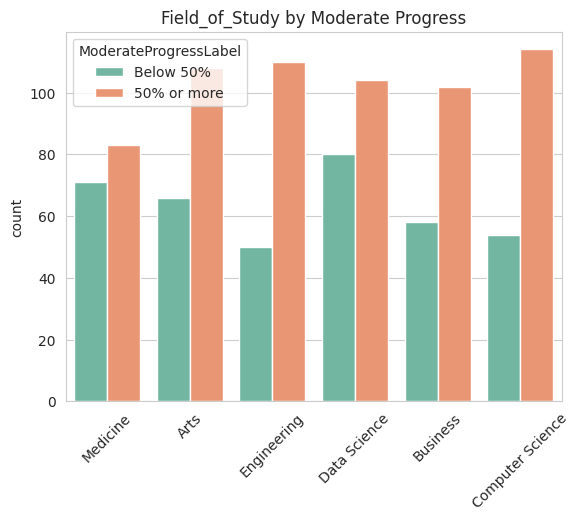

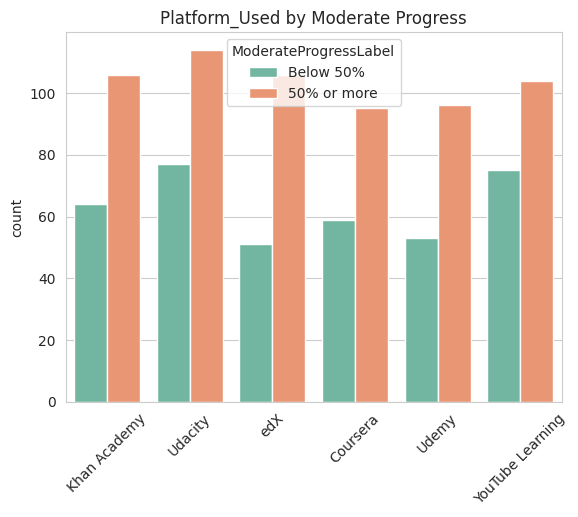

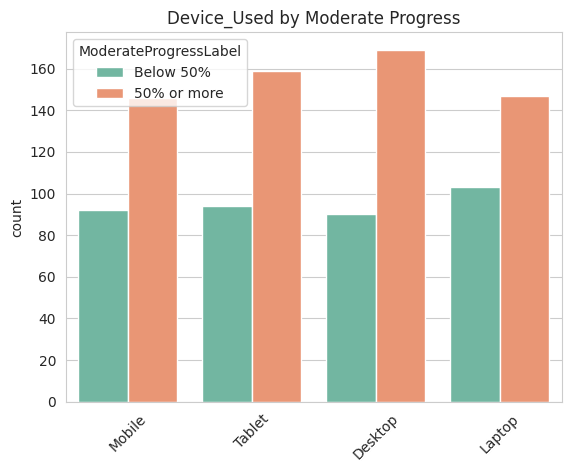

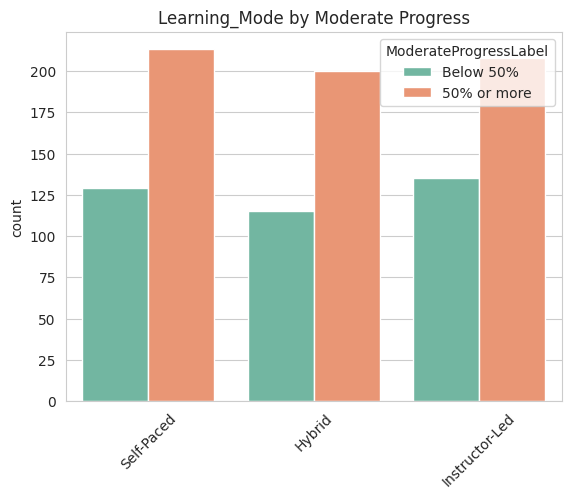

In [31]:
# Countplots of categorical features by MeaningfulProgress
for feature in categorical_features:
    sns.countplot(x=feature, hue='ModerateProgressLabel', data=course_df, palette='Set2')
    plt.title(f'{feature} by Moderate Progress')
    plt.xticks(rotation=45)
    plt.xlabel('')
    plt.show()

The categorical features show a bit more separation than the numerical features for both `MeaningfulProgress` and `ModerateProgress`. `Education_Level`, `Field_of_Study`, and `Platform_Used` seem to stand out the most overall, while `Country` also shows some variation. For `ModerateProgress`, `Device_Used` and `Learning_Mode` look a bit more noticeable than they did for `MeaningfulProgress`. `Gender` looks less distinct across both targets. Overall, some of the categorical features may be useful in the models, but none of them look overwhelmingly strong on their own.

In [32]:
# Progress rates by categorical feature
for feature in categorical_features:
    print(feature)
    print(course_df.groupby(feature)['MeaningfulProgress'].mean().sort_values(ascending=False))
    print()

Country
Country
Canada          0.423529
Pakistan        0.414634
UAE             0.413333
UK              0.397436
Germany         0.394737
China           0.389610
South Africa    0.386364
India           0.357143
Australia       0.347222
France          0.342857
Japan           0.338028
USA             0.295775
Brazil          0.294118
Name: MeaningfulProgress, dtype: float64

Gender
Gender
Female    0.393064
Male      0.378549
Other     0.338279
Name: MeaningfulProgress, dtype: float64

Education_Level
Education_Level
Postgraduate     0.426829
High School      0.362445
Professional     0.350365
Undergraduate    0.342629
Name: MeaningfulProgress, dtype: float64

Field_of_Study
Field_of_Study
Engineering         0.412500
Computer Science    0.398810
Data Science        0.391304
Arts                0.379310
Business            0.343750
Medicine            0.285714
Name: MeaningfulProgress, dtype: float64

Platform_Used
Platform_Used
Khan Academy        0.405882
Udemy               0.3

In [33]:
# Progress rates by categorical feature
for feature in categorical_features:
    print(feature)
    print(course_df.groupby(feature)['ModerateProgress'].mean().sort_values(ascending=False))
    print()

Country
Country
India           0.700000
Pakistan        0.670732
Canada          0.658824
France          0.657143
South Africa    0.647727
UAE             0.640000
Germany         0.631579
China           0.623377
Australia       0.611111
UK              0.602564
Japan           0.591549
USA             0.535211
Brazil          0.505882
Name: ModerateProgress, dtype: float64

Gender
Gender
Female    0.664740
Male      0.637224
Other     0.560831
Name: ModerateProgress, dtype: float64

Education_Level
Education_Level
Postgraduate     0.646341
Professional     0.624088
High School      0.606987
Undergraduate    0.605578
Name: ModerateProgress, dtype: float64

Field_of_Study
Field_of_Study
Engineering         0.687500
Computer Science    0.678571
Business            0.637500
Arts                0.620690
Data Science        0.565217
Medicine            0.538961
Name: ModerateProgress, dtype: float64

Platform_Used
Platform_Used
edX                 0.675159
Udemy               0.644295
Kh

The grouped progress rates make the category differences easier to see. `Education_Level`, `Field_of_Study`, and `Device_Used` look like the strongest categorical features so far. `Country` and `Platform_Used` vary a bit too, while `Gender` and `Learning_Mode` seem less important. The patterns are there, but they are not especially large.

## 9. Data Preprocessing

After exploring the dataset, the next step is to prepare the features for modelling. I start by selecting the predictor variables, separating them from the target, and converting the categorical features into a numerical format.

In [34]:
# Set the target for the first model
target_1 = 'MeaningfulProgress'
target_2 = 'ModerateProgress'
# Define X and y
X = course_df[predictor_features]
y = course_df[target_1]
z = course_df[target_2]

In [35]:
# Convert categorical features into dummy variables
X = pd.get_dummies(X, drop_first=True).astype(int)

In [36]:
# Check the transformed feature set
X.head()

,Age,Daily_Learning_Hours,Quizzes_Attempted,Assignments_Submitted,Satisfaction_Score(1-5),Country_Brazil,Country_Canada,Country_China,Country_France,Country_Germany,...,Platform_Used_Khan Academy,Platform_Used_Udacity,Platform_Used_Udemy,Platform_Used_YouTube Learning,Platform_Used_edX,Device_Used_Laptop,Device_Used_Mobile,Device_Used_Tablet,Learning_Mode_Instructor-Led,Learning_Mode_Self-Paced
0,21,4,7,3,2,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,1
1,49,3,0,8,2,0,0,0,0,0,...,0,1,0,0,0,0,0,1,0,1
2,20,2,4,3,3,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,1
3,38,5,12,1,5,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
4,44,5,7,1,4,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,1


After encoding the categorical features, the next step is to split the data into training and test sets. This lets me train the model on one part of the data and evaluate it on unseen observations.

In [37]:
# Import train-test split
from sklearn.model_selection import train_test_split
# Import the model and evaluation metrics
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [38]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [39]:
X_train, X_test, z_train, z_test = train_test_split(
    X, z, test_size=0.2, random_state=1
)

In [40]:
# Check the shapes of the split datasets
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 37), (200, 37), (800,), (200,))

In [41]:
X_train.shape, X_test.shape, z_train.shape, z_test.shape

((800, 37), (200, 37), (800,), (200,))

## 10. Model Building

I start with logistic regression as a baseline model. Since the target is binary, logistic regression is a sensible first model and gives a clear benchmark before trying anything more flexible.

In [42]:
# Fit the logistic regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [43]:
# Make predictions on the test set
y_pred = log_model.predict(X_test)

In [44]:
# Check the accuracy
accuracy_score(y_test, y_pred)

0.625

In [45]:
# Look at the confusion matrix
confusion_matrix(y_test, y_pred)

array([[114,  22],
       [ 53,  11]])

In [46]:
# Print the classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.84      0.75       136
           1       0.33      0.17      0.23        64

    accuracy                           0.62       200
   macro avg       0.51      0.51      0.49       200
weighted avg       0.57      0.62      0.58       200



The logistic regression model gives an accuracy of 62.5%, but the other metrics show that its performance is uneven across the two classes. It does a reasonably good job predicting learners below the 75% threshold, but it struggles to identify learners who actually reach MeaningfulProgress. In particular, recall for class 1 is low, which means the model misses many of the learners who made 75% or more progress. So while logistic regression is a useful baseline, it does not seem to capture the positive class very well in its current form.

In [47]:
# Fit the logistic regression model
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, z_train)

LogisticRegression(max_iter=1000)

In [48]:
# Make predictions on the test set
z_pred = log_model.predict(X_test)

In [49]:
# Print the classification report
print(classification_report(z_test, z_pred))

              precision    recall  f1-score   support

           0       0.25      0.09      0.13        82
           1       0.56      0.82      0.67       118

    accuracy                           0.52       200
   macro avg       0.41      0.45      0.40       200
weighted avg       0.44      0.52      0.45       200



In [50]:
# Look at the confusion matrix
confusion_matrix(z_test, z_pred)

array([[ 7, 75],
       [21, 97]])

In [51]:
# Print the classification report
print(classification_report(z_test, z_pred))

              precision    recall  f1-score   support

           0       0.25      0.09      0.13        82
           1       0.56      0.82      0.67       118

    accuracy                           0.52       200
   macro avg       0.41      0.45      0.40       200
weighted avg       0.44      0.52      0.45       200



The logistic regression model gives an accuracy of 52.0%, which is not especially strong. It does a much better job predicting learners who reached `ModerateProgress` than learners who stayed below the 50% threshold. In particular, recall for class `1` is high, but recall for class `0` is very low, so the model misses many of the lower-progress learners. This means the model leans quite heavily toward predicting the positive class. Overall, logistic regression picks up moderate progress more easily than meaningful progress, but the results are still quite uneven across the two classes.

To see whether a more flexible model performs better, I next fit a decision tree and compare the results with logistic regression.

In [52]:
# Import the decision tree model
from sklearn.tree import DecisionTreeClassifier

In [53]:
# Fit the decision tree model
tree_model = DecisionTreeClassifier(random_state=1)
tree_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [54]:
# Make predictions on the test set
tree_pred = tree_model.predict(X_test)

In [55]:
# Check the accuracy
accuracy_score(y_test, tree_pred)

0.535

In [56]:
# Look at the confusion matrix
confusion_matrix(y_test, tree_pred)

array([[77, 59],
       [34, 30]])

In [57]:
# Print the classification report
print(classification_report(y_test, tree_pred))

              precision    recall  f1-score   support

           0       0.69      0.57      0.62       136
           1       0.34      0.47      0.39        64

    accuracy                           0.54       200
   macro avg       0.52      0.52      0.51       200
weighted avg       0.58      0.54      0.55       200



The decision tree performs worse than logistic regression in terms of overall accuracy, with a score of 53.5% compared with 62.5%. However, it does a better job of identifying learners who actually reached `MeaningfulProgress`. In particular, recall for class `1` is noticeably higher in the decision tree model, which means it catches more of the positive cases. This comes at the cost of more false positives and weaker overall performance. Taken together, the comparison suggests that logistic regression is the stronger baseline model overall, but the decision tree is less conservative when predicting meaningful progress.

Comparing the two models, logistic regression performed better overall in terms of accuracy, but it struggled to identify learners who actually reached meaningful progress. The decision tree had lower overall accuracy, but it picked up more of the positive cases. This suggests a trade-off between overall correctness and the ability to detect learners who made substantial progress.

In [58]:
# Fit the decision tree model
tree_model = DecisionTreeClassifier(random_state=1)
tree_model.fit(X_train, z_train)

DecisionTreeClassifier(random_state=1)

In [59]:
# Make predictions on the test set
tree_pred = tree_model.predict(X_test)

In [60]:
# Check the accuracy
accuracy_score(z_test, tree_pred)

0.52

In [61]:
# Look at the confusion matrix
confusion_matrix(z_test, tree_pred)

array([[33, 49],
       [47, 71]])

In [62]:
# Print the classification report
print(classification_report(z_test, tree_pred))

              precision    recall  f1-score   support

           0       0.41      0.40      0.41        82
           1       0.59      0.60      0.60       118

    accuracy                           0.52       200
   macro avg       0.50      0.50      0.50       200
weighted avg       0.52      0.52      0.52       200



The decision tree and logistic regression both end up with an accuracy of 52.0%, but they make different kinds of mistakes. Logistic regression is much better at picking up learners who reached `ModerateProgress`, but it does a poor job on the learners who stayed below the 50% threshold. The decision tree is more balanced across the two classes, even though it is weaker than logistic regression on class `1`. So neither model is especially strong overall, but the logistic regression leans more toward predicting moderate progress, while the decision tree spreads its predictions more evenly.

Comparing the two models, neither one clearly outperformed the other overall, since they both gave the same accuracy. The main difference is that logistic regression was better at picking up learners who reached `ModerateProgress`, while the decision tree gave more balanced results across the two classes. So the trade-off here is between stronger detection of the positive class and more even performance overall.

## 11. Conclusion

In this project, I looked at whether learner and course-related features could be used to predict progress in online learning. I used two different targets: `ModerateProgress` for learners who reached at least 50% of a course, and `MeaningfulProgress` for learners who reached at least 75%.

From the exploratory analysis, the categorical features generally looked more useful than the numerical ones when viewed individually. In particular, `Education_Level`, `Field_of_Study`, and `Device_Used` seemed to stand out more than the other features.

The modelling results were mixed. For `MeaningfulProgress`, logistic regression had better overall accuracy, but it missed many of the learners who actually reached the 75% threshold. The decision tree picked up more of those learners, but with worse overall performance. For `ModerateProgress`, both models gave the same accuracy, but logistic regression was stronger on the positive class, while the decision tree was more balanced across the two classes.

Overall, the dataset does seem to contain some predictive signal, but neither target was especially easy to model well with these simple methods. The results suggest that progress in online learning depends on patterns that are only partly captured by the available features.